## Overview figures

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

# making sure plots & clusters are reproducible
np.random.seed(42)

# custom functions
import sc_toolbox as sct

Running Scanpy 1.8.2, on 2025-01-29 09:47.


In [2]:
## path variables
adata_dir = '/mnt/smb/Niklas/GLPG_data_temp/240731_GLPG_annotated.h5ad'
data_dir = '/home/niklas/projects/GLPG_drug_perturbations/01_data/'
out_dir = '/home/niklas/projects/GLPG_drug_perturbations/04_annotation/04_01_data/'

In [3]:
## plotting variables
sc.settings.figdir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig4/'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## new adata dir
adata_dir = '/mnt/smb/Niklas/GLPG_data_temp/240811_GLPG_annotated.h5ad'

In [5]:
## load anndata object
adata = sc.read(adata_dir)

In [6]:
## have a look at the adata object: 442k cells x 25000 genes
adata

AnnData object with n_obs × n_vars = 442439 × 24500
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2', 'cell_type', 'group', 'ChromiumBatch', 'LibraryPrepBatch', 'SeqBatch', 'ashcroft_score', 'body_weight_d0', 'body_weight_d1', 'body_weight_d2', 'body_weight_d3', 'body_weight_d4', 'body_weight_d5', 'body_weight_d6', 'body_weight_d7', 'body_weight_d8', 'body_weight_d9', 'body_weight_d10', 'body_weight_d11', 'body_weight_d12', 'body_weight_d13', 'body_weight_d14', 'body_weight_d15', 'body_weight_d16', 'body_weight_d17', 'body_weight_d18', 'body_weight_d19', 'body_weight_d20', 'body_weight_d21', 'body_weight_min', 'body_weight_max', 'delta_max_body_weight', 'delta_body_weight_d7_10', 'delta_body_weight_d14_d21'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispe

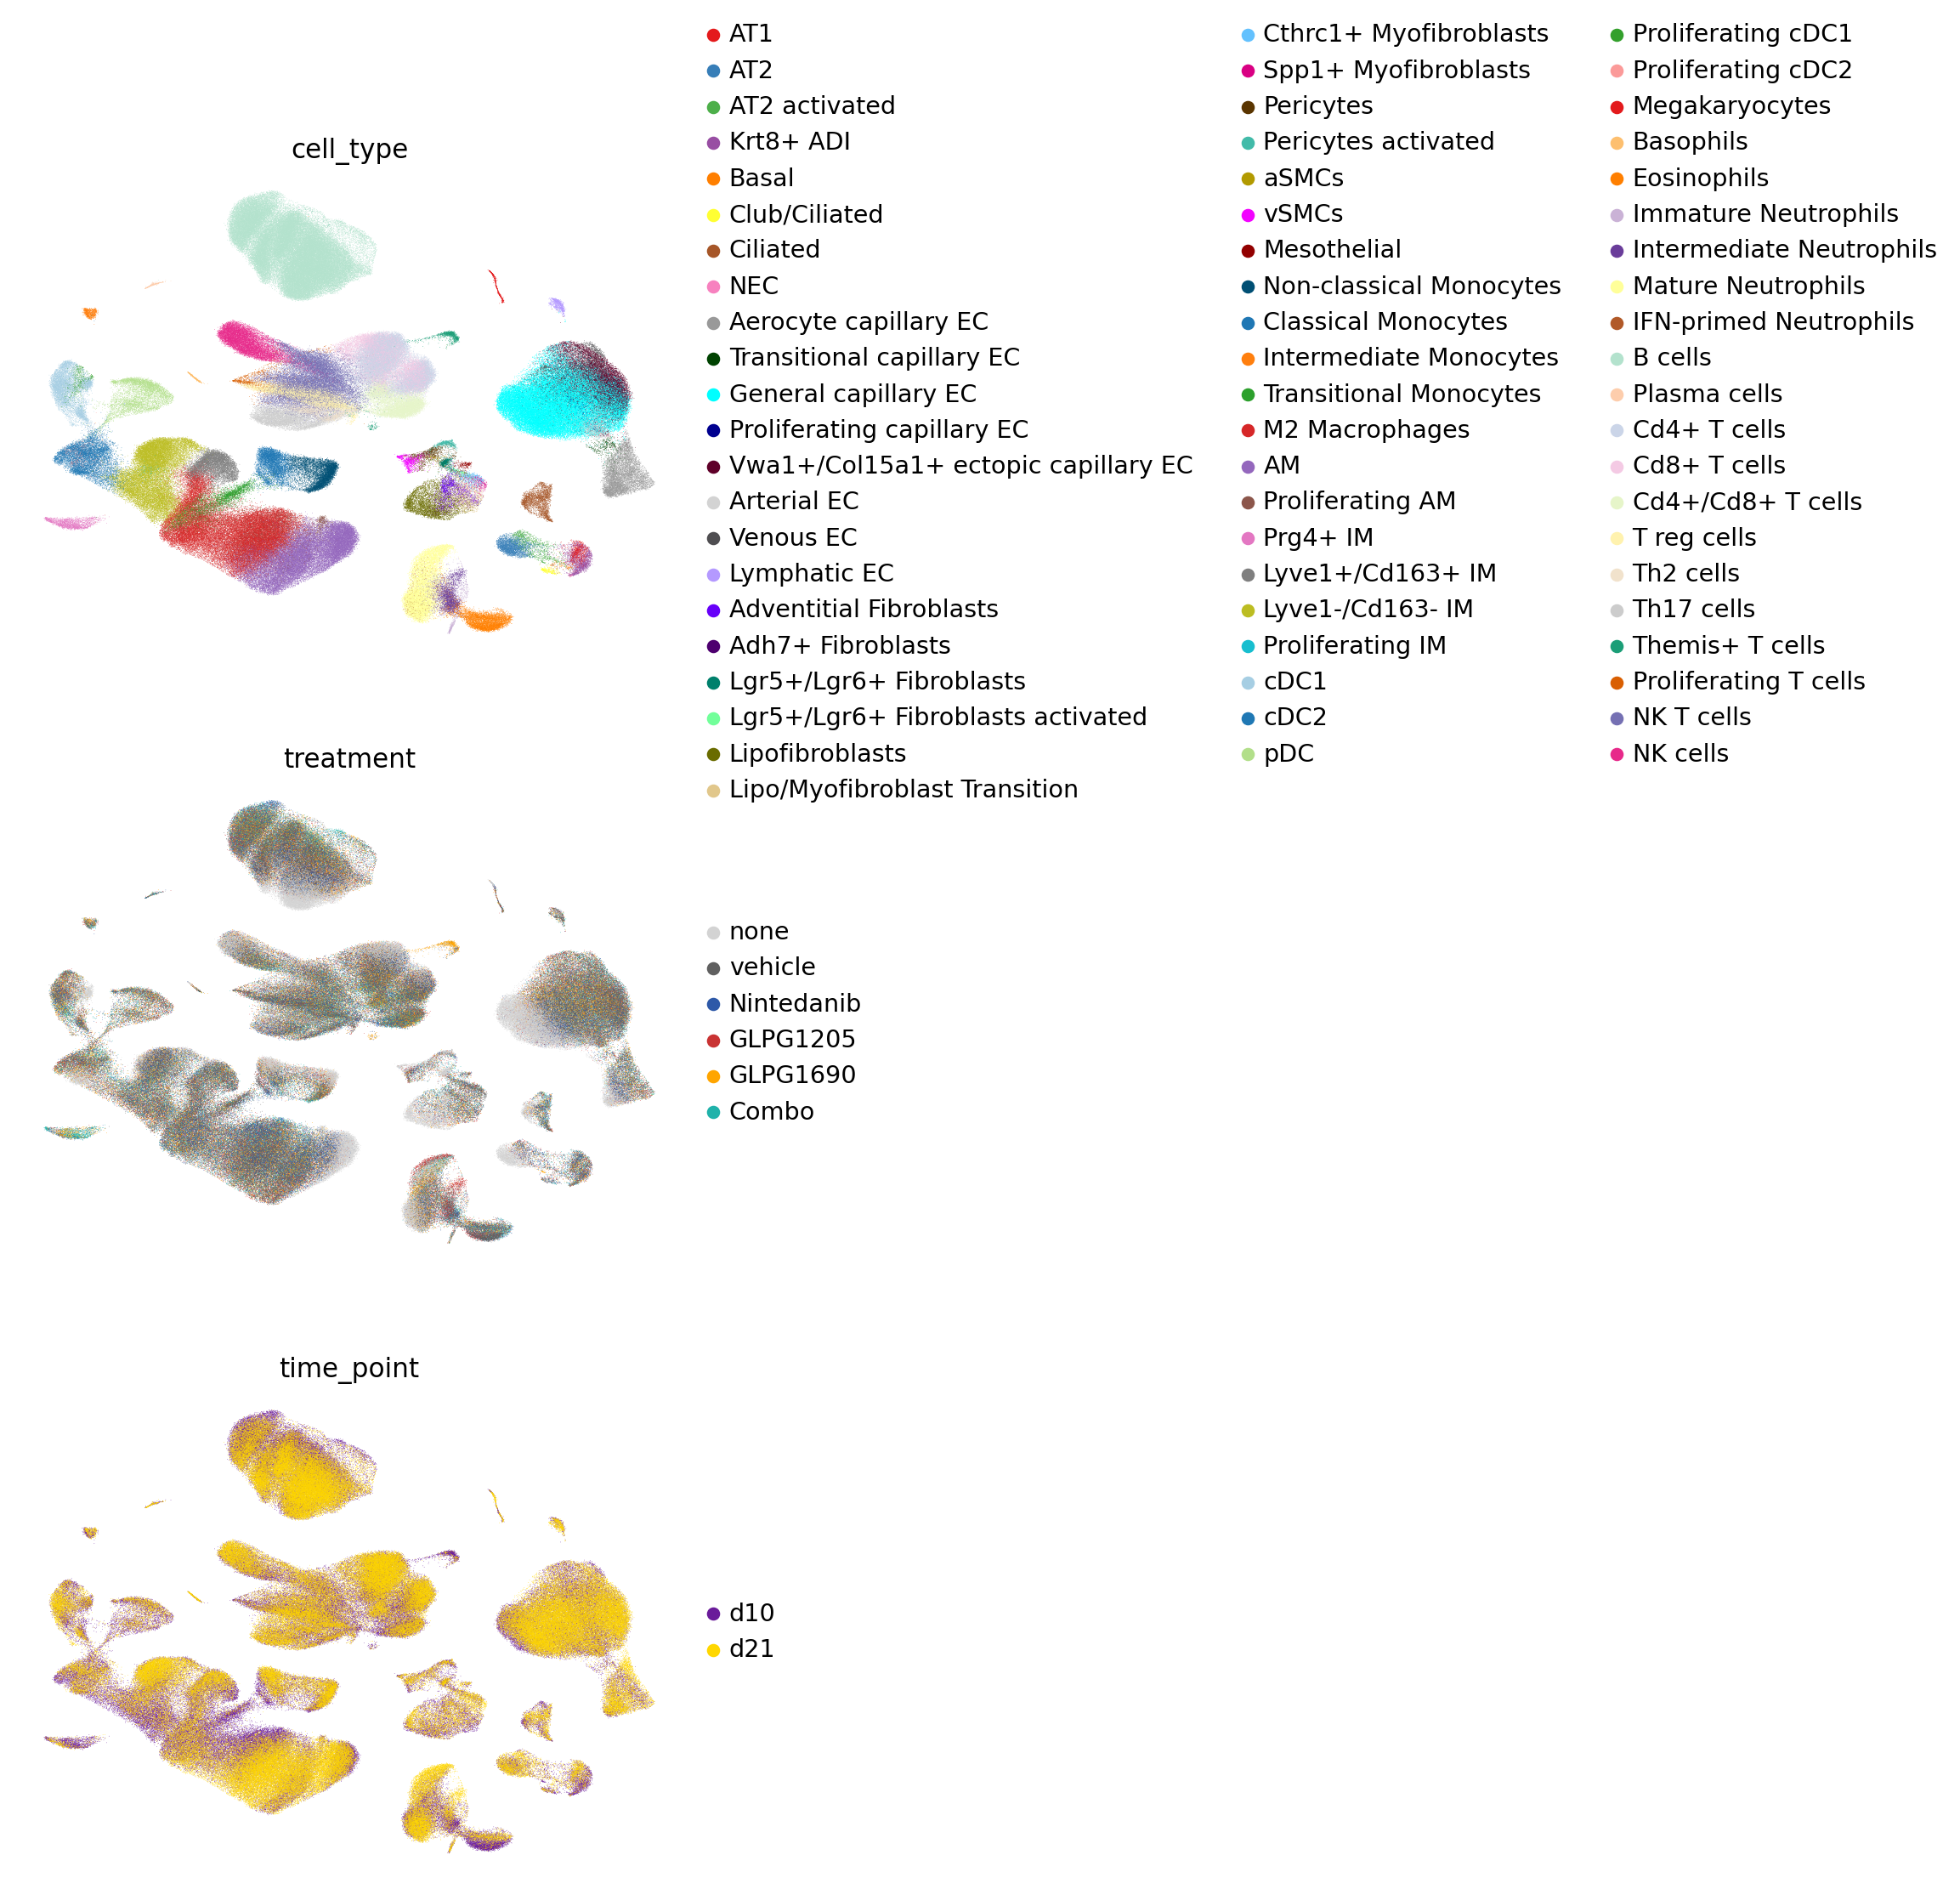

In [7]:
sc.pl.umap(adata, color = ['cell_type','treatment','time_point'], ncols = 1, frameon = False, size = 0.4)

### Marker gene analysis

In [8]:
## new annotation for this purpose
annot_dict = {'AT1' : 'Epithelial',
              'AT2' : 'Epithelial',
              'AT2 activated' : 'Epithelial',
              'Krt8+ ADI' : 'Epithelial',
              'Basal' : 'Epithelial',
              'Club/Ciliated' : 'Epithelial',
              'Ciliated' : 'Epithelial',
              'NEC' : 'Epithelial',
              'Aerocyte capillary EC' : 'Endothelial',
              'Transitional capillary EC' : 'Endothelial',
              'General capillary EC' : 'Endothelial',
              'Proliferating capillary EC' : 'Endothelial',
              'Vwa1+/Col15a1+ ectopic capillary EC' : 'Endothelial',
              'Arterial EC' : 'Endothelial',
              'Venous EC' : 'Endothelial',
              'Lymphatic EC' : 'Endothelial',
              'Adventitial Fibroblasts' : 'Stromal',
              'Adh7+ Fibroblasts' : 'Stromal',
              'Lgr5+/Lgr6+ Fibroblasts' : 'Stromal',
              'Lgr5+/Lgr6+ Fibroblasts activated' : 'Stromal',
              'Lipofibroblasts' : 'Stromal',
              'Lipo/Myofibroblast Transition' : 'Stromal',
              'Cthrc1+ Myofibroblasts' : 'Stromal',
              'Spp1+ Myofibroblasts' : 'Stromal',
              'Pericytes' : 'Stromal',
              'Pericytes activated' : 'Stromal',
              'aSMCs' : 'Stromal',
              'vSMCs' : 'Stromal',
              'Mesothelial' : 'Stromal',
              'Non-classical Monocytes' : 'Stromal',
              'Classical Monocytes' : 'Stromal',
              'Intermediate Monocytes' : 'Stromal',
              'Transitional Monocytes' : 'Stromal',
              'M2 Macrophages' : 'MNPs',
              'AM' : 'MNPs',
              'Proliferating AM' : 'MNPs',
              'Prg4+ IM' : 'MNPs',
              'Lyve1+/Cd163+ IM' : 'MNPs',
              'Lyve1-/Cd163- IM' : 'MNPs',
              'Proliferating IM' : 'MNPs',
              'cDC1' : 'MNPs',
              'cDC2' : 'MNPs',
              'pDC' : 'MNPs',
              'Proliferating cDC1' : 'MNPs',
              'Proliferating cDC2' : 'MNPs',
              'Megakaryocytes' : 'MNPs',
              'B cells' : 'Lymphocytes',
              'Plasma cells' : 'Lymphocytes',
              'Cd4+ T cells' : 'Lymphocytes',
              'Cd8+ T cells' : 'Lymphocytes',
              'Cd4+/Cd8+ T cells' : 'Lymphocytes',
              'T reg cells' : 'Lymphocytes',
              'Th2 cells' : 'Lymphocytes',
              'Th17 cells' : 'Lymphocytes',
              'Themis+ T cells' : 'Lymphocytes',
              'Proliferating T cells' : 'Lymphocytes',
              'NK T cells' : 'Lymphocytes',
              'NK cells' : 'Lymphocytes'
             }

In [9]:
adata.obs['ct_marker_calc'] = [annot_dict[ct] if ct in annot_dict else ct for ct in adata.obs['cell_type']]

/home/niklas/miniconda3/envs/niche_fibrosis_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1228: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  c.reorder_categories(natsorted(c.categories), inplace=True)
... storing 'ct_marker_calc' as categorical


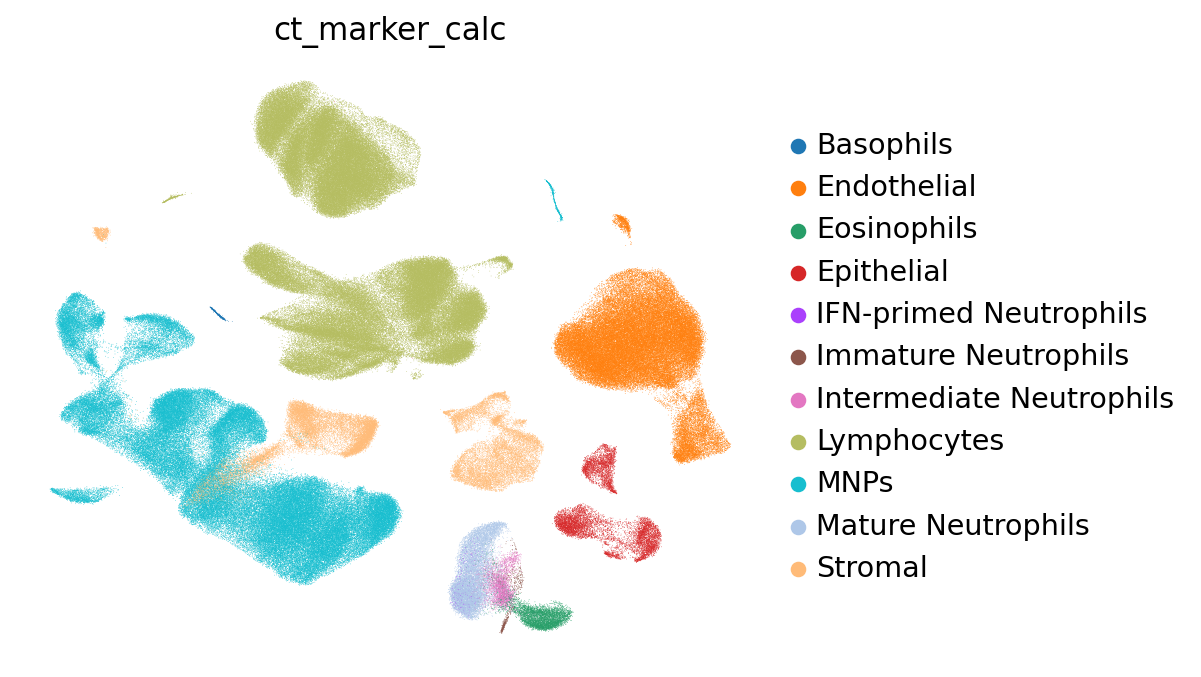

In [10]:
sc.pl.umap(adata, color = ['ct_marker_calc'], ncols = 1, frameon = False, size = 0.4)

### Compute marker genes

In [11]:
## compute marker genes
sc.tl.rank_genes_groups(adata, groupby='ct_marker_calc', method='wilcoxon')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:18:24)


In [12]:
## function to add pct expressed 
def add_pct(adata, tab, ids, group_by, thresh_min=0, gene_label='gene'):
    for ident in ids:
        
        # subset to cell type of interest
        cells_oi = adata.obs_names[adata.obs[group_by] == ident]
        # compute fraction (%) of cell type expressing each marker genes
        data_temp_oi = pd.DataFrame(((adata[cells_oi].layers['counts'] > 0).sum(0)
                / adata[cells_oi].layers['counts'].shape[0]).T, index=adata.var_names)
        
        # subset to all other cells (background)
        cells_background = adata.obs_names[adata.obs[group_by] != ident]
        # compute fraction (%) to background expressing each marker genes
        data_temp_background = pd.DataFrame(((adata[cells_background].layers['counts'] > 0).sum(0)
                / adata[cells_background].layers['counts'].shape[0]).T, index=adata.var_names)
        
        if gene_label == 'index':
            tab[f'pct_cell_type'] = data_temp_oi.reindex(tab.index.values).values
            tab[f'pct_background'] = data_temp_background.reindex(tab.index.values).values
        else:
            tab[f'pct_cell_type'] = data_temp_oi.reindex(tab.loc[:, gene_label]).values
            tab[f'pct_background'] = data_temp_background.reindex(tab.loc[:, gene_label]).values
    return tab

In [13]:
## pandas df of all marker genes
result = adata.uns['rank_genes_groups']
marker_df = []
for cluster in result['names'].dtype.names:
    ct_table = pd.DataFrame({'gene': result['names'][cluster],
                            'score': result['scores'][cluster],
                            'logfoldchange': result['logfoldchanges'][cluster],
                            'pval': result['pvals'][cluster],
                            'pval_adj': result['pvals_adj'][cluster],
                            'cell_type': cluster
                           })
    ## compute pct expressed for cell type and background
    ct_table = add_pct(adata, ct_table, [cluster], group_by = 'ct_marker_calc')
    marker_df.append(ct_table)
marker_df = pd.concat(marker_df)
marker_df.head()

,gene,score,logfoldchange,pval,pval_adj,cell_type,pct_cell_type,pct_background
0,Ccl3,40.087612,8.902534,0.000000e+00,0.000000e+00,Basophils,0.980462,0.054447
1,Ifitm1,38.109264,7.109100,0.000000e+00,0.000000e+00,Basophils,0.964476,0.052001
2,Ccl9,36.677841,5.388589,1.647591e-294,1.345533e-290,Basophils,0.946714,0.148741
3,Cyp11a1,36.468513,12.963467,3.500805e-291,2.144243e-287,Basophils,0.888099,0.000611
4,Gata2,36.143250,5.256797,4.749846e-286,2.327424e-282,Basophils,0.918295,0.123168


In [14]:
## filter marker gene table
markers_filtered = marker_df[marker_df['logfoldchange'] > 2]
markers_filtered = marker_df[marker_df['pct_background'] < 0.1]
markers_filtered = marker_df[marker_df['pct_cell_type'] > 0.25]

In [15]:
markers_filtered.head(10)

,gene,score,logfoldchange,pval,pval_adj,cell_type,pct_cell_type,pct_background
0,Ccl3,40.087612,8.902534,0.000000e+00,0.000000e+00,Basophils,0.980462,0.054447
1,Ifitm1,38.109264,7.109100,0.000000e+00,0.000000e+00,Basophils,0.964476,0.052001
2,Ccl9,36.677841,5.388589,1.647591e-294,1.345533e-290,Basophils,0.946714,0.148741
3,Cyp11a1,36.468513,12.963467,3.500805e-291,2.144243e-287,Basophils,0.888099,0.000611
4,Gata2,36.143250,5.256797,4.749846e-286,2.327424e-282,Basophils,0.918295,0.123168
5,Ccl4,36.115391,8.002720,1.300557e-285,5.310609e-282,Basophils,0.889876,0.025487
6,Hdc,35.846249,5.947994,2.103847e-281,7.363465e-278,Basophils,0.920071,0.049346
7,Lilr4b,34.997715,4.906243,2.437225e-268,7.464003e-265,Basophils,0.902309,0.146672
8,Cyp4f18,34.459110,4.222163,3.288940e-260,8.953226e-257,Basophils,0.920071,0.196870
9,Fxyd5,34.162445,3.257644,8.738127e-256,2.140841e-252,Basophils,0.980462,0.517548


In [16]:
## select only top genes per cell type

## identify the max score for each gene across all cell types
gene_max_scores = markers_filtered.groupby('gene')['score'].max().reset_index()
gene_max_scores = gene_max_scores.rename(columns={'score': 'max_score'})

## merge max score back to original df
markers_filtered = pd.merge(markers_filtered, gene_max_scores, on='gene')
## filter row where score it score == max score
top_markers = markers_filtered[markers_filtered['score'] == markers_filtered['max_score']]
## drop helper col
top_markers = top_markers.drop(columns=['max_score'])

## sort df
top_markers = top_markers.sort_values(['cell_type','logfoldchange'], ascending = [True,False])

In [17]:
top_markers.head(10)

,gene,score,logfoldchange,pval,pval_adj,cell_type,pct_cell_type,pct_background
44,Ms4a2,33.627213,14.199768,6.715506e-248,1.495726e-244,Basophils,0.818828,0.000163
183,Fcer1a,26.915192,13.661073,1.458465e-159,8.715215e-157,Basophils,0.655417,0.000124
10,Cyp11a1,36.468513,12.963467,3.500805e-291,2.144243e-287,Basophils,0.888099,0.000611
566,Mcpt8,17.941462,12.692428,5.596371e-72,1.038720e-69,Basophils,0.436945,0.000131
274,Csrp3,23.265379,12.639087,9.941286e-120,3.866056e-117,Basophils,0.566607,0.000195
117,Cpa3,29.679028,12.056477,1.432217e-193,1.403573e-190,Basophils,0.722913,0.000396
66,Cd200r3,32.042152,9.989934,2.823828e-225,4.323987e-222,Basophils,0.781528,0.004377
361,Il6,21.841335,9.843422,9.396697e-106,2.989858e-103,Basophils,0.532860,0.001935
681,Il4,16.302700,9.313752,9.442615e-60,1.360847e-57,Basophils,0.397869,0.001279
1081,1110028F11Rik,12.661303,9.000050,9.687866e-37,7.325701e-35,Basophils,0.309059,0.000946


In [18]:
## generate dict with top 20 markers
top_genes_dict = (
    top_markers.sort_values(by='logfoldchange', ascending=False)
    .groupby('cell_type')
    .apply(lambda x: list(x.nlargest(20, 'logfoldchange')['gene']))
    .to_dict()
)

In [19]:
#sc.pl.dotplot(adata,
#              var_names = top_genes_dict,
#              groupby = 'ct_marker_calc',
#              standard_scale = 'var'
#             )

In [20]:
## after comparing and assessing cell type markers computed within the following settings:
## within granulocyte subset
## overall (all 60+ cell states)
## all granuloyte subset vs. major lineage subsets (see this script)
celltype_markers={'Pan-granulocyte': ['Cxcr2','Itgam','Mxd1'],
                  'Basophils' : ['Fcer1a','Mcpt8','Cyp11a1','Cpa3','Ccl3','Gata2'],
                  'Eosinophils' : ['Siglecf','Clec4n','Clec5a','Gcnt1','Il4ra','Xbp1','Tarm1','Ccrl2'],
                  'Immature Neutrophils' : ['Cebpe','Camp','Ltf','Ngp','Ly6g','Itgb2l'],
                  'Intermediate Neutrophils' : ['Mmp9','Rdh12','Stfa2l1','Cirbp','Osm','Cpne2'],
                  'Mature Neutrophils' : ['Cebpd','Il1b','Wfdc17','S100a8','S100a9','Lrg1'],
                  'IFN primed Neutrophils' : ['Ifit3','Ifit3b','Oasl1','Oas3','Irf7','Ifit1']
                 }

### Final Figure

In [21]:
adata.obs['ct_marker_calc'].cat.categories

Index(['Basophils', 'Endothelial', 'Eosinophils', 'Epithelial',
       'IFN-primed Neutrophils', 'Immature Neutrophils',
       'Intermediate Neutrophils', 'Lymphocytes', 'MNPs', 'Mature Neutrophils',
       'Stromal'],
      dtype='object')

In [22]:
## reorder cell type labels
adata.obs['ct_marker_calc'] = adata.obs['ct_marker_calc'].cat.reorder_categories(['Basophils',
                                                                                  'Eosinophils',
                                                                                  'Immature Neutrophils',
                                                                                  'Intermediate Neutrophils',
                                                                                  'Mature Neutrophils',
                                                                                  'IFN-primed Neutrophils',
                                                                                  'Epithelial',
                                                                                  'Endothelial',
                                                                                  'Stromal',
                                                                                  'MNPs',
                                                                                  'Lymphocytes'
])

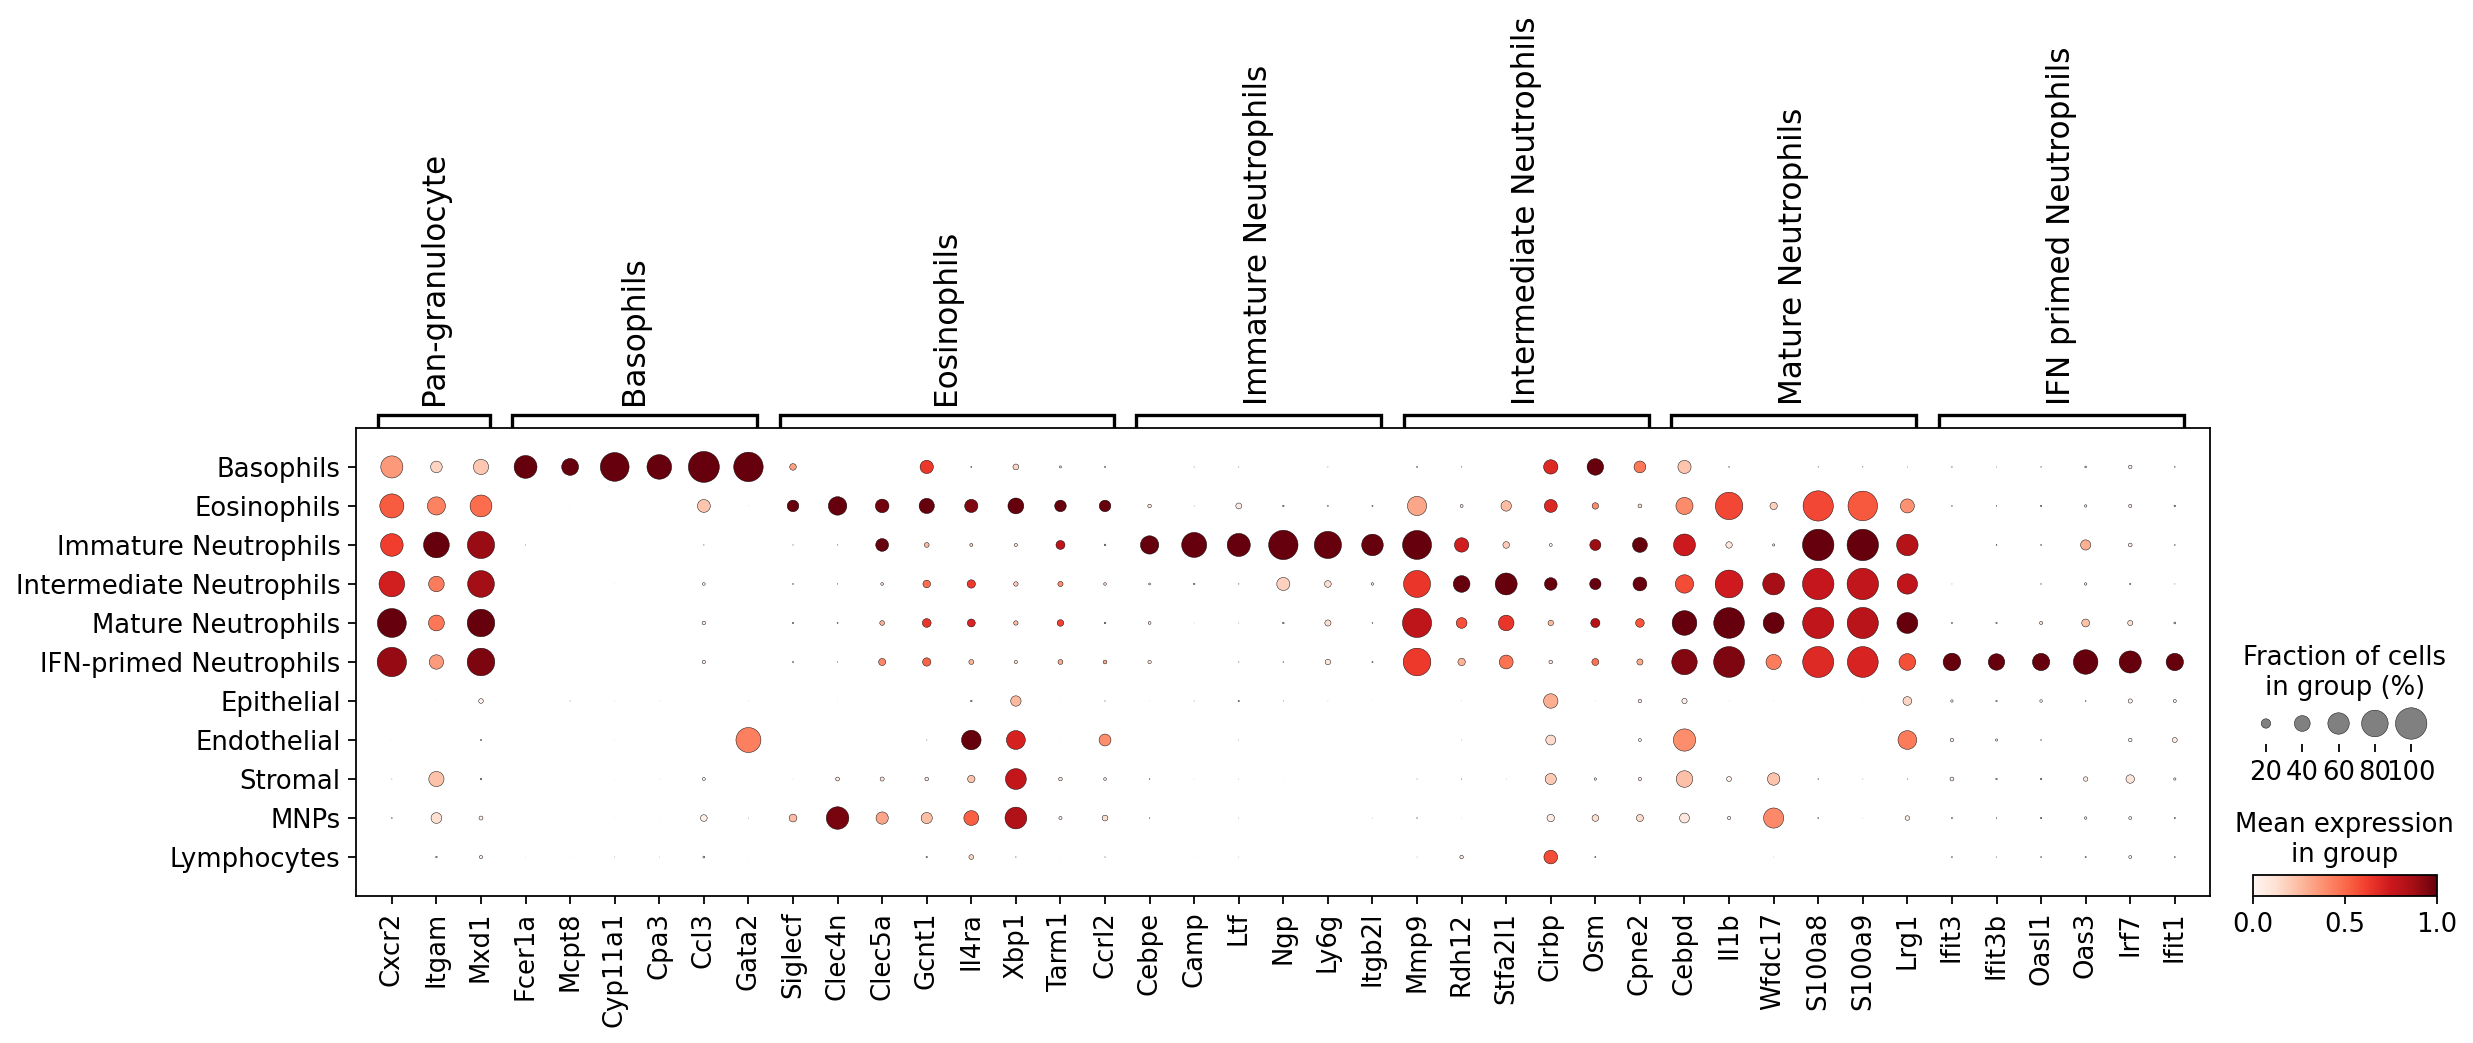

In [23]:
## visualize all marker genes
sc.pl.dotplot(adata,
              groupby = 'ct_marker_calc',
              var_names = celltype_markers,
              standard_scale = 'var',
              cmap = 'Reds',
              save = 'granulocyte_marker_overview.pdf'
             )

In [24]:
from matplotlib import colors
gray_red = colors.LinearSegmentedColormap.from_list("grouping", ["lightgray", "red", "darkred"], N=128)

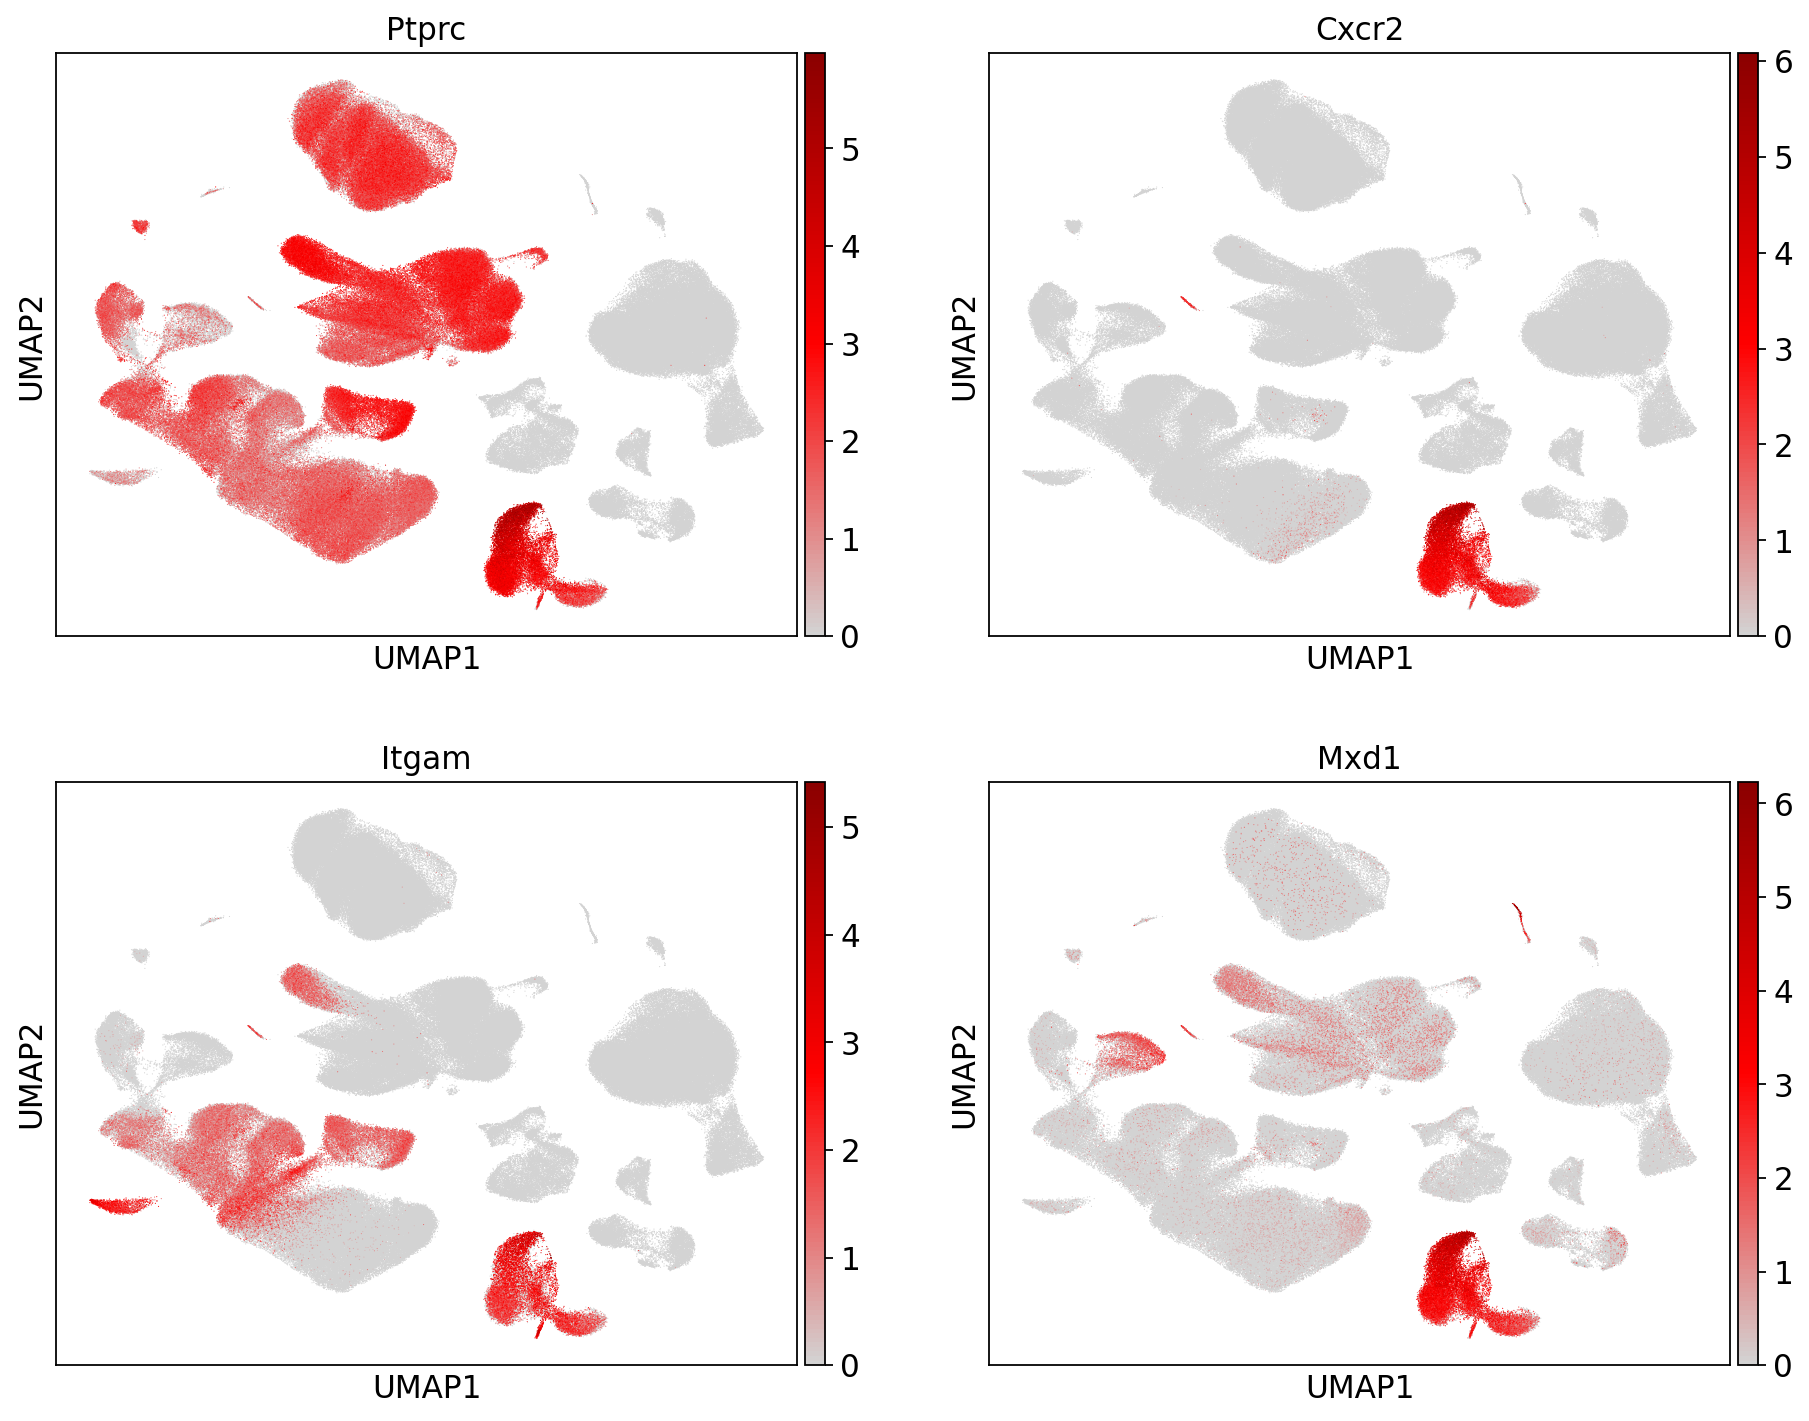

In [25]:
## UMAP of pan-granulocyte marker genes
sc.pl.umap(adata,
           color = ['Ptprc','Cxcr2','Itgam','Mxd1'],
           ncols = 2,
           cmap = gray_red,
           size = 1,
           save = '_pan_granulocyte_marker.pdf'
          )

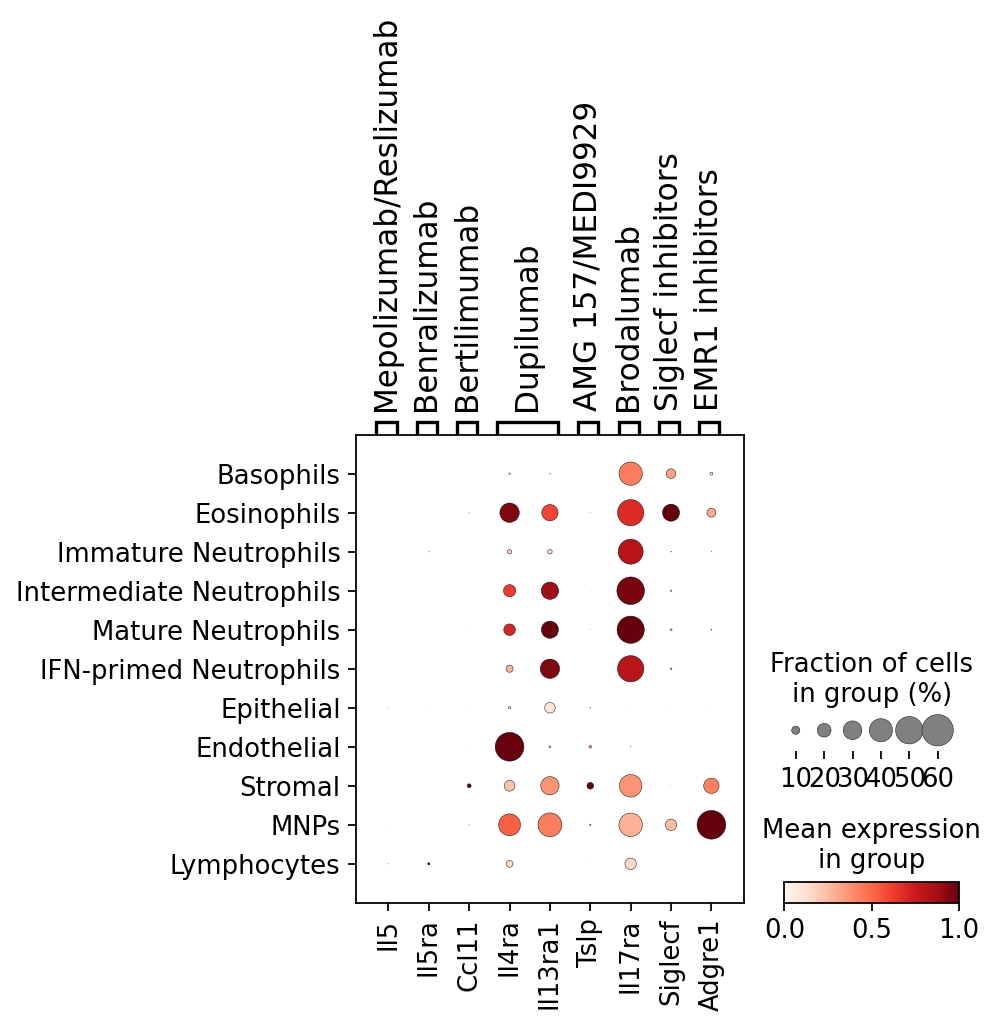

In [26]:
## dotplot of biological targets
eosinophil_drug_targets = {'Mepolizumab/Reslizumab': ['Il5'],
                           'Benralizumab': ['Il5ra'],
                           'Bertilimumab': ['Ccl11'],
                           'Dupilumab': ['Il4ra', 'Il13ra1'],
                           'AMG 157/MEDI9929': ['Tslp'],
                           'Brodalumab': ['Il17ra'],
                           'Siglecf inhibitors': ['Siglecf'],
                           'EMR1 inhibitors': ['Adgre1']
}

sc.pl.dotplot(adata,
              groupby = 'ct_marker_calc',
              var_names = eosinophil_drug_targets,
              standard_scale = 'var',
              cmap = 'Reds',
              #save = 'granulocyte_marker_overview.pdf'
             )